In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import skimage
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

## Bài 1:

(np.float64(-0.5), np.float64(8.5), np.float64(6.5), np.float64(-0.5))

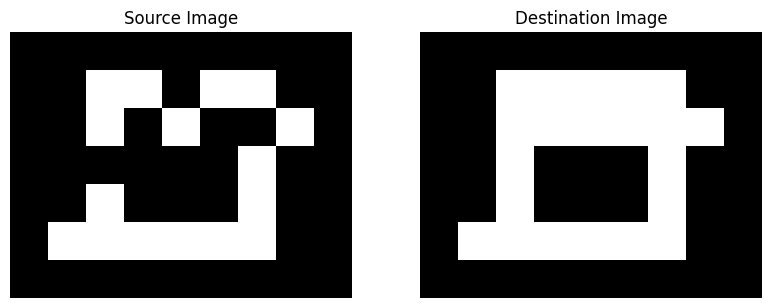

In [31]:
source_img = cv2.imread('source.png', cv2.IMREAD_GRAYSCALE)
destination_img = cv2.imread('destination.png', cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(source_img, cmap='gray')
plt.title('Source Image')
plt.axis('off')

# Ảnh destination (mục tiêu)
plt.subplot(1, 3, 2)
plt.imshow(destination_img, cmap='gray')
plt.title('Destination Image')
plt.axis('off')

Phép OPEN:
$$
A \circ B = (A \ominus B) \oplus B
$$

Phép CLOSE:
$$
A \bullet B = (A \oplus B) \ominus B
$$

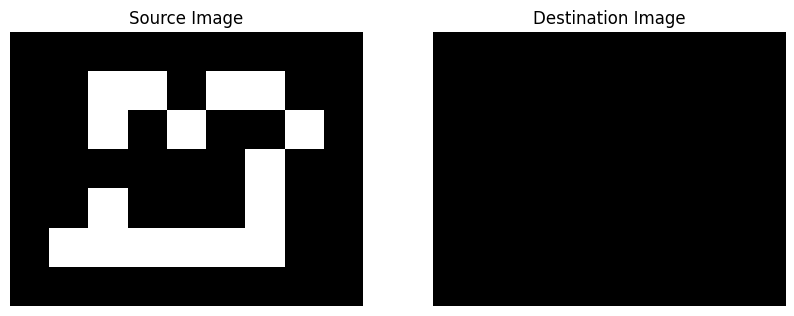

In [36]:
source_img = cv2.imread('source.png', cv2.IMREAD_GRAYSCALE)
kernel = np.ones((2, 2), np.uint8)
anchor = (0, 1)

img_open = cv2.erode(source_img, kernel, anchor=anchor, iterations=1)
img_open = cv2.dilate(img_open, kernel, anchor=anchor, iterations=1)

img_close = cv2.dilate(img_open, kernel, anchor=anchor, iterations=1)
img_close = cv2.erode(img_close, kernel, anchor=anchor, iterations=1)

cv2.imwrite('destination_result.png', img_close)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(source_img, cmap='gray')  
plt.title('Source Image')
plt.axis('off')  


plt.subplot(1, 2, 2)
plt.imshow(img_close, cmap='gray')
plt.title('Destination Image')
plt.axis('off')


plt.show()

## Bài 2:

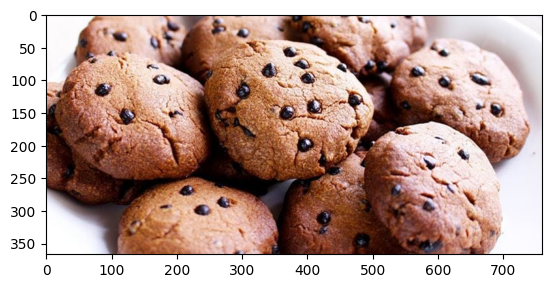

In [15]:
img = cv2.imread('original.jpg')

# Chuyển từ BGR sang RGB (OpenCV đọc ảnh theo BGR)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Hiển thị ảnh RGB
plt.imshow(img_rgb)

plt.show()

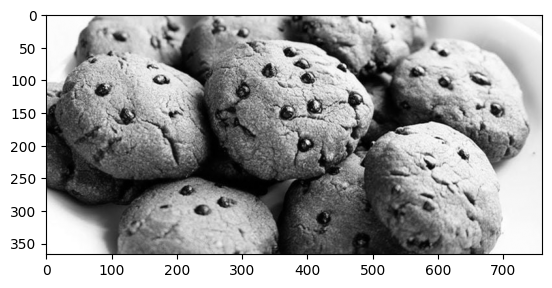

In [17]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img_gray, cmap='gray')

plt.show()

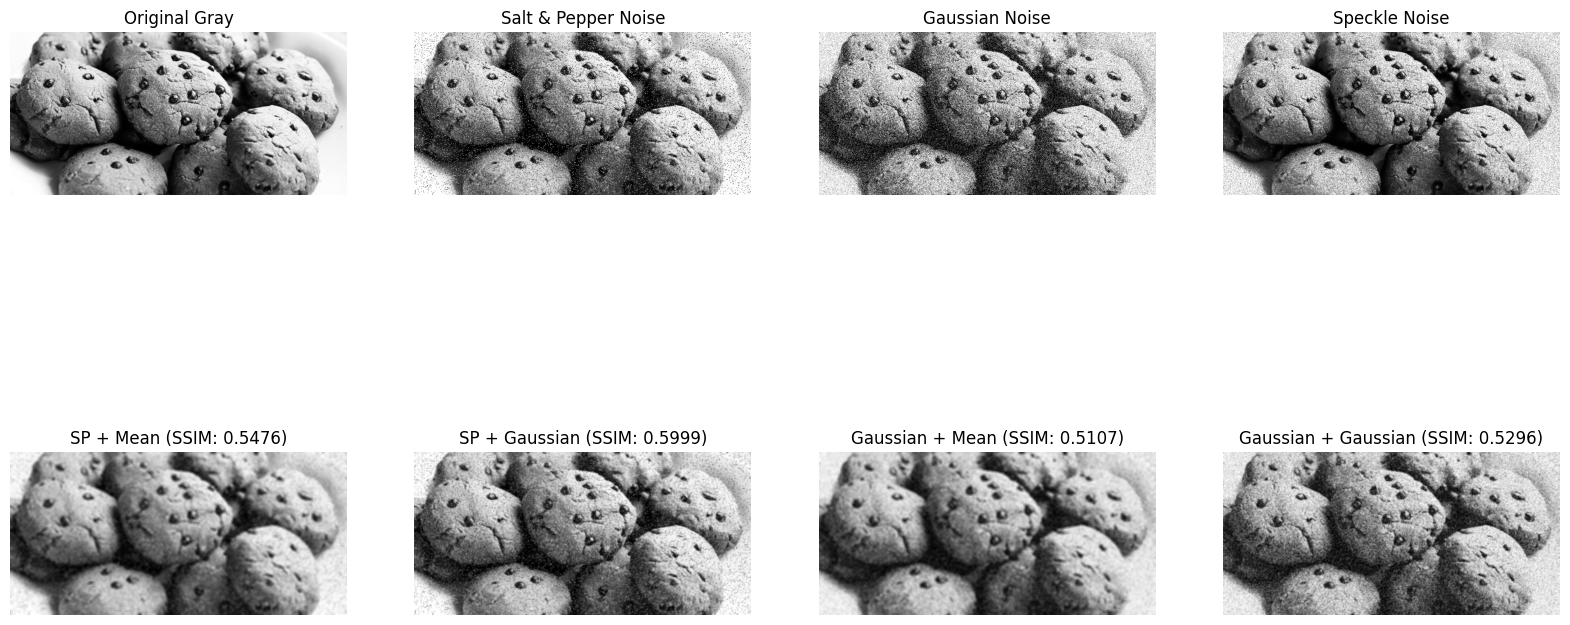

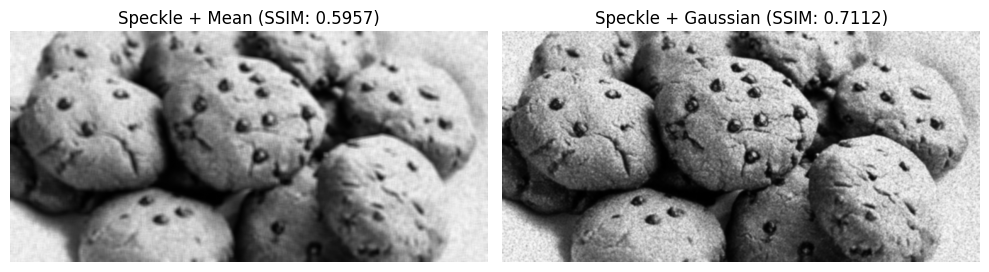

Nhận xét:
SSIM của ảnh salt & pepper sau khi khử nhiễu bằng mean filter: 0.5476
SSIM của ảnh salt & pepper sau khi khử nhiễu bằng Gaussian filter: 0.5999
SSIM của ảnh Gaussian noise sau khi khử nhiễu bằng mean filter: 0.5107
SSIM của ảnh Gaussian noise sau khi khử nhiễu bằng Gaussian filter: 0.5296
SSIM của ảnh Speckle sau khi khử nhiễu bằng mean filter: 0.5957
SSIM của ảnh Speckle sau khi khử nhiễu bằng Gaussian filter: 0.7112
Gaussian filter hiệu quả hơn cho nhiễu salt & pepper.
Gaussian filter hiệu quả hơn cho nhiễu Gaussian.
Gaussian filter hiệu quả hơn cho nhiễu speckle.
Kết luận
Mean filter phù hợp hơn cho nhiễu Salt & Pepper.
Gaussian filter phù hợp hơn cho nhiễu Gaussian.
Gaussian filter là lựa chọn tốt hơn cho nhiễu Speckle.


In [25]:
def add_salt_and_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05):
    noisy = np.copy(image)
    num_salt = np.ceil(salt_prob * image.size).astype(int)
    coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape]
    noisy[coords[0], coords[1]] = 255
    num_pepper = np.ceil(pepper_prob * image.size).astype(int)
    coords = [np.random.randint(0, i - 1, num_pepper) for i in image.shape]
    noisy[coords[0], coords[1]] = 0
    return noisy

def add_gaussian_noise(image, mean=0, sigma=0.25):
    noise = np.random.normal(mean, sigma, image.shape)
    img_normalized = image / 255.0
    noisy = img_normalized + noise
    noisy = np.clip(noisy, 0, 1) * 255
    return noisy.astype(np.uint8)
def add_speckle_noise(image, sigma=0.25):
    noise = np.random.randn(*image.shape) * sigma
    img_normalized = image / 255.0
    noisy = img_normalized + img_normalized * noise
    noisy = np.clip(noisy, 0, 1) * 255
    return noisy.astype(np.uint8)


img_color = cv2.imread('original.jpg')
img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

img_sp_noise = add_salt_and_pepper_noise(img_gray, salt_prob=0.05, pepper_prob=0.05)
img_gaussian_noise = add_gaussian_noise(img_gray, mean=0, sigma=0.25)
img_speckle_noise = add_speckle_noise(img_gray, sigma=0.25)

kernel_size = 7

mean_filter = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size * kernel_size)
img_sp_mean = cv2.filter2D(img_sp_noise, -1, mean_filter)
img_gaussian_mean = cv2.filter2D(img_gaussian_noise, -1, mean_filter)
img_speckle_mean = cv2.filter2D(img_speckle_noise, -1, mean_filter)

img_sp_gaussian = cv2.GaussianBlur(img_sp_noise, (kernel_size, kernel_size), sigmaX=1.0)
img_gaussian_gaussian = cv2.GaussianBlur(img_gaussian_noise, (kernel_size, kernel_size), sigmaX=1.0)
img_speckle_gaussian = cv2.GaussianBlur(img_speckle_noise, (kernel_size, kernel_size), sigmaX=1.0)


ssim_sp_mean = ssim(img_gray, img_sp_mean, data_range=img_sp_mean.max() - img_sp_mean.min())
ssim_sp_gaussian = ssim(img_gray, img_sp_gaussian, data_range=img_sp_gaussian.max() - img_sp_gaussian.min())
ssim_gaussian_mean = ssim(img_gray, img_gaussian_mean, data_range=img_gaussian_mean.max() - img_gaussian_mean.min())
ssim_gaussian_gaussian = ssim(img_gray, img_gaussian_gaussian, data_range=img_gaussian_gaussian.max() - img_gaussian_gaussian.min())
ssim_speckle_mean = ssim(img_gray, img_speckle_mean, data_range=img_speckle_mean.max() - img_speckle_mean.min())
ssim_speckle_gaussian = ssim(img_gray, img_speckle_gaussian, data_range=img_speckle_gaussian.max() - img_speckle_gaussian.min())

plt.figure(figsize=(20, 10))

plt.subplot(2, 4, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Original Gray')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(img_sp_noise, cmap='gray')
plt.title('Salt & Pepper Noise')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(img_gaussian_noise, cmap='gray')
plt.title('Gaussian Noise')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(img_speckle_noise, cmap='gray')
plt.title('Speckle Noise')
plt.axis('off')


plt.subplot(2, 4, 5)
plt.imshow(img_sp_mean, cmap='gray')
plt.title(f'SP + Mean (SSIM: {ssim_sp_mean:.4f})')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(img_sp_gaussian, cmap='gray')
plt.title(f'SP + Gaussian (SSIM: {ssim_sp_gaussian:.4f})')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(img_gaussian_mean, cmap='gray')
plt.title(f'Gaussian + Mean (SSIM: {ssim_gaussian_mean:.4f})')
plt.axis('off')

plt.subplot(2, 4, 8)
plt.imshow(img_gaussian_gaussian, cmap='gray')
plt.title(f'Gaussian + Gaussian (SSIM: {ssim_gaussian_gaussian:.4f})')
plt.axis('off')

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_speckle_mean, cmap='gray')
plt.title(f'Speckle + Mean (SSIM: {ssim_speckle_mean:.4f})')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_speckle_gaussian, cmap='gray')
plt.title(f'Speckle + Gaussian (SSIM: {ssim_speckle_gaussian:.4f})')
plt.axis('off')
plt.tight_layout()
plt.show()

print("Nhận xét:")
print(f"SSIM của ảnh salt & pepper sau khi khử nhiễu bằng mean filter: {ssim_sp_mean:.4f}")
print(f"SSIM của ảnh salt & pepper sau khi khử nhiễu bằng Gaussian filter: {ssim_sp_gaussian:.4f}")
print(f"SSIM của ảnh Gaussian noise sau khi khử nhiễu bằng mean filter: {ssim_gaussian_mean:.4f}")
print(f"SSIM của ảnh Gaussian noise sau khi khử nhiễu bằng Gaussian filter: {ssim_gaussian_gaussian:.4f}")
print(f"SSIM của ảnh Speckle sau khi khử nhiễu bằng mean filter: {ssim_speckle_mean:.4f}")
print(f"SSIM của ảnh Speckle sau khi khử nhiễu bằng Gaussian filter: {ssim_speckle_gaussian:.4f}")

if ssim_sp_mean > ssim_sp_gaussian:
    print("Mean filter hiệu quả hơn cho nhiễu salt & pepper.")
else:
    print("Gaussian filter hiệu quả hơn cho nhiễu salt & pepper.")

if ssim_gaussian_mean > ssim_gaussian_gaussian:
    print("Mean filter hiệu quả hơn cho nhiễu Gaussian.")
else:
    print("Gaussian filter hiệu quả hơn cho nhiễu Gaussian.")
if ssim_speckle_mean > ssim_speckle_gaussian:
    print("Mean filter hiệu quả hơn cho nhiễu speckle.")
else:
    print("Gaussian filter hiệu quả hơn cho nhiễu speckle.")
print("Kết luận")
print("Mean filter phù hợp hơn cho nhiễu Salt & Pepper.")
print("Gaussian filter phù hợp hơn cho nhiễu Gaussian.")
print("Gaussian filter là lựa chọn tốt hơn cho nhiễu Speckle.")

## Bài 3:

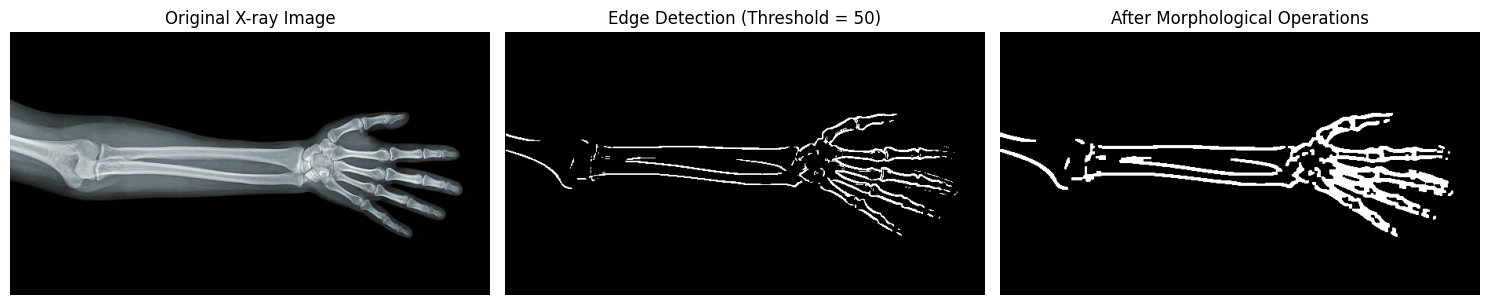

In [30]:
def edge_detection_range_3x3(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img
    blur = cv2.GaussianBlur(gray, (3, 3), sigmaX=0)
    edge_img = np.zeros_like(blur, dtype=np.float32)
    rows, cols = blur.shape
    for y in range(1, rows - 1):
        for x in range(1, cols - 1):
            block = blur[y-1:y+2, x-1:x+2]            
            max_val = np.max(block)
            min_val = np.min(block)            
            range_val = max_val - min_val            
            edge_img[y, x] = range_val
    return edge_img

def apply_threshold(edge_img, threshold):
    binary_edge = np.zeros_like(edge_img, dtype=np.uint8)
    binary_edge[edge_img > threshold] = 255
    return binary_edge

def apply_morphological_operations(binary_edge):
    kernel = np.ones((3, 3), np.uint8)    
    dilated = cv2.dilate(binary_edge, kernel, iterations=2)    
    cleaned = cv2.erode(dilated, kernel, iterations=1)
    return cleaned

img = cv2.imread('xray.jpg')
edge_img = edge_detection_range_3x3(img)

threshold = 50  
binary_edge = apply_threshold(edge_img, threshold)

morph_img = apply_morphological_operations(binary_edge)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original X-ray Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(binary_edge, cmap='gray')
plt.title(f'Edge Detection (Threshold = {threshold})')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(morph_img, cmap='gray')
plt.title('After Morphological Operations')
plt.axis('off')

plt.tight_layout()
plt.show()